# DAY 4 — NATURAL LANGUAGE PROCESSING PRACTICALS

This notebook contains the NLP practicals completed during the AI Bootcamp.

Topics covered:
- NLP and NLTK
- Word Cloud
- Spam Detection
- Sentiment Analysis
- Resume Scanner
- Transformers
- LLM

## 1. NLP and NLTK

Natural Language Processing (NLP) helps computers work with human language.

NLTK (Natural Language Toolkit) provides tools for tasks such as tokenization, stopword removal, stemming, and lemmatization.

In [1]:
import nltk

print("NLTK imported successfully.")

NLTK imported successfully.


In [2]:
nltk.download("punkt_tab")
nltk.download("stopwords")

print("NLTK resources downloaded successfully.")

NLTK resources downloaded successfully.


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/nirbhay/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/nirbhay/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords

text = "Artificial intelligence is changing how students learn and solve problems."

sentences = sent_tokenize(text)
words = word_tokenize(text)

print("Sentences:", sentences)
print("Words:", words)

Sentences: ['Artificial intelligence is changing how students learn and solve problems.']
Words: ['Artificial', 'intelligence', 'is', 'changing', 'how', 'students', 'learn', 'and', 'solve', 'problems', '.']


### Removing Stopwords

Stopwords are common words that may not carry much useful information for some NLP tasks. We can remove them from the tokenized text using NLTK.

In [4]:
stop_words = set(stopwords.words("english"))

filtered_words = [
    word for word in words
    if word.lower() not in stop_words and word.isalpha()
]

print("Original words:", words)
print("After stopword removal:", filtered_words)

Original words: ['Artificial', 'intelligence', 'is', 'changing', 'how', 'students', 'learn', 'and', 'solve', 'problems', '.']
After stopword removal: ['Artificial', 'intelligence', 'changing', 'students', 'learn', 'solve', 'problems']


### Stemming and Lemmatization

Stemming reduces words to a simpler root form, while lemmatization converts words to their meaningful base form.

In [5]:
from nltk.stem import PorterStemmer, WordNetLemmatizer

nltk.download("wordnet")

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

sample_words = ["studying", "studies", "connected", "learning", "better"]

stemmed_words = [stemmer.stem(word) for word in sample_words]
lemmatized_words = [lemmatizer.lemmatize(word) for word in sample_words]

print("Original:", sample_words)
print("Stemmed:", stemmed_words)
print("Lemmatized:", lemmatized_words)

[nltk_data] Downloading package wordnet to /Users/nirbhay/nltk_data...


Original: ['studying', 'studies', 'connected', 'learning', 'better']
Stemmed: ['studi', 'studi', 'connect', 'learn', 'better']
Lemmatized: ['studying', 'study', 'connected', 'learning', 'better']


## 2. Word Cloud

A word cloud represents frequently occurring words using different visual sizes. Words that appear more often are displayed more prominently.

In [6]:
!pip install wordcloud

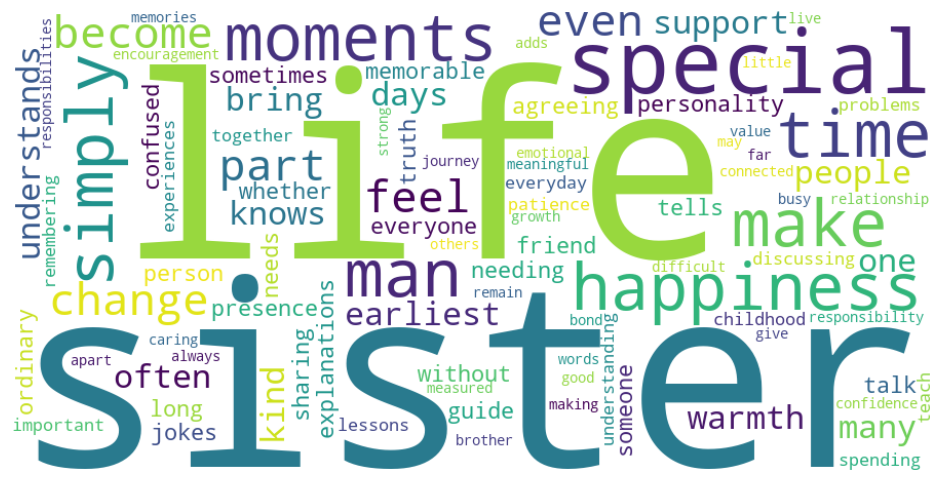

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = """
A sister can bring a special kind of warmth, support, and happiness into a man's life.
She is often one of the people who knows him from his earliest days and understands
many parts of his personality without needing long explanations. A sister can be a
friend when he needs someone to talk to, a guide when he is confused, and sometimes
the person who tells him the truth when everyone else is simply agreeing with him.
Her presence can make ordinary moments more memorable, whether it is sharing jokes,
discussing everyday problems, remembering childhood experiences, or simply spending
time together. She can also teach important lessons about patience, understanding,
responsibility, and caring for others. As life changes, the relationship between a
brother and sister may change too, but the bond can remain strong even when they live
far apart or become busy with their own responsibilities. Her encouragement can give
confidence during difficult times, while her happiness can make his good moments feel
even more special. A sister adds emotional value to a man's life that cannot always
be measured in words. She becomes a part of his memories, his growth, and his journey,
making life feel a little more connected and meaningful.
"""

wordcloud = WordCloud(
    width=900,
    height=450,
    background_color="white"
).generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

## 3. Spam Detection

A spam detector classifies messages into categories such as spam and normal messages by learning patterns from example text.

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

messages = [
    "You have won a free movie ticket",
    "Congratulations, claim your cash reward now",
    "Limited offer, click to receive your gift",
    "Can you send me today's lecture notes?",
    "The lab submission is due tomorrow",
    "Are you coming to the project meeting?"
]

labels = [
    "Spam",
    "Spam",
    "Spam",
    "Ham",
    "Ham",
    "Ham"
]

vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(messages)

model = MultinomialNB()
model.fit(X_train, labels)

print("Spam detection model trained successfully.")

Spam detection model trained successfully.


In [9]:
test_messages = [
    "You are selected for a free shopping voucher",
    "Can you share the notes after today's class?",
    "Urgent! Claim your prize before midnight"
]

X_test = vectorizer.transform(test_messages)
predictions = model.predict(X_test)

for message, prediction in zip(test_messages, predictions):
    print(f"Message: {message}")
    print(f"Prediction: {prediction}")
    print()

Message: You are selected for a free shopping voucher
Prediction: Ham

Message: Can you share the notes after today's class?
Prediction: Ham

Message: Urgent! Claim your prize before midnight
Prediction: Spam



In [10]:
extra_messages = [
    "Get your free shopping voucher today",
    "You have won a special reward",
    "Claim your prize now",
    "Free coupon waiting for you",
    "Please send the assignment file",
    "Let's meet in the library after class",
    "The practical session starts at 10 AM",
    "Can you share the project document?"
]

extra_labels = [
    "Spam", "Spam", "Spam", "Spam",
    "Ham", "Ham", "Ham", "Ham"
]

messages.extend(extra_messages)
labels.extend(extra_labels)

X_train = vectorizer.fit_transform(messages)
model.fit(X_train, labels)

print("Model retrained with additional examples.")

Model retrained with additional examples.


In [11]:
test_messages = [
    "You are selected for a free shopping voucher",
    "Can you share the notes after today's class?",
    "Urgent! Claim your prize before midnight"
]

X_test = vectorizer.transform(test_messages)
predictions = model.predict(X_test)

for message, prediction in zip(test_messages, predictions):
    print(f"Message: {message}")
    print(f"Prediction: {prediction}")
    print()

Message: You are selected for a free shopping voucher
Prediction: Spam

Message: Can you share the notes after today's class?
Prediction: Ham

Message: Urgent! Claim your prize before midnight
Prediction: Spam



## 4. Sentiment Analysis

Sentiment analysis identifies the emotional tone of a piece of text. Here, we will check whether a sentence is positive, negative, or neutral.

In [12]:
!pip install textblob

In [13]:
from textblob import TextBlob

sentences = [
    "I really enjoyed today's AI practical session.",
    "The project was difficult and frustrating.",
    "The class started at 10 AM today."
]

for sentence in sentences:
    polarity = TextBlob(sentence).sentiment.polarity

    if polarity > 0:
        sentiment = "Positive"
    elif polarity < 0:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"

    print("Text:", sentence)
    print("Polarity:", polarity)
    print("Sentiment:", sentiment)
    print()

Text: I really enjoyed today's AI practical session.
Polarity: 0.5
Sentiment: Positive

Text: The project was difficult and frustrating.
Polarity: -0.45
Sentiment: Negative

Text: The class started at 10 AM today.
Polarity: 0.0
Sentiment: Neutral



## 5. Resume Scanner

A resume scanner can extract useful information from a resume and check whether important skills or keywords are present.

Here, we will use simple keyword matching to identify relevant skills.

In [14]:
resume_text = """
B.Tech CSE student with experience in Python, Java, SQL, machine learning,
data analysis, and computer vision. Worked on academic projects using
NumPy, pandas, OpenCV, and scikit-learn.
"""

skills = [
    "Python",
    "Java",
    "SQL",
    "Machine Learning",
    "Data Analysis",
    "Computer Vision",
    "OpenCV",
    "scikit-learn"
]

found_skills = []

for skill in skills:
    if skill.lower() in resume_text.lower():
        found_skills.append(skill)

print("Skills found in resume:")
for skill in found_skills:
    print("-", skill)

print("\nTotal skills found:", len(found_skills))

Skills found in resume:
- Python
- Java
- SQL
- Machine Learning
- Data Analysis
- Computer Vision
- OpenCV
- scikit-learn

Total skills found: 8


## 6. Transformers

Transformers are neural network architectures that process text by using attention mechanisms to understand relationships between words.

They are widely used in modern NLP applications such as translation, text classification, and question answering.

In [15]:
!pip install transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 3.4 MB/s  0:00:03a 0:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 4.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 4.2 MB/s  0:00:014.4 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 4.4 MB/s  0:00:00m 4.6 MB/s eta 0:00:01
  Attempting uninstall: click
    Found existing installation: click 8.4.1
    Uninstalling click-8.4.1:
      Successfully uninstalled click-8.4.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [transformers]0m 5/6 [transformers]ub]


In [16]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")

texts = [
    "I am very happy with my project.",
    "This assignment is confusing and frustrating."
]

results = classifier(texts)

for text, result in zip(texts, results):
    print("Text:", text)
    print("Label:", result["label"])
    print("Score:", round(result["score"], 3))
    print()

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Text: I am very happy with my project.
Label: POSITIVE
Score: 1.0

Text: This assignment is confusing and frustrating.
Label: NEGATIVE
Score: 1.0



## 7. Large Language Model (LLM)

Large Language Models are AI models trained on large amounts of text to understand and generate human language.

In this practical, we will use a pretrained model to generate a short text response.

In [17]:
from transformers import pipeline

generator = pipeline("text-generation", model="distilgpt2")

prompt = "Artificial intelligence is changing education because"

result = generator(
    prompt,
    max_new_tokens=40,
    num_return_sequences=1
)

print("Generated text:")
print(result[0]["generated_text"])

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Generated text:
Artificial intelligence is changing education because of the fact that it can be used to create a better education for all. The future is bright.


## Conclusion

The practicals covered basic NLP processing, text classification, sentiment analysis, keyword extraction, transformers, and text generation using pretrained models.